In [1]:
# ==================== 环境配置 ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os
from datetime import datetime

In [2]:
# ==================== 全局变量 ====================
SITE_ID = "Cockatoo"                
BUILDING_TYPE = "office"       
TARGET = f"{SITE_ID}_{BUILDING_TYPE}_Giovanni"   # 明确目标列名称
DATA_SAVE_PATH = "E:/bishe/preprocessed_data（Cockatoo）.csv"  # 确保路径正确
SOURCE_BUILDINGS = ['Cockatoo_office_Pansy', 'Cockatoo_office_Elbert', 'Cockatoo_office_Delores']

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu
已删除旧的模型文件: pretrained_model.pth

=== 使用 3 折时间序列交叉验证进行预训练 ===


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11680\2831111490.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_11680\2831111490.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_11680\2831111490.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



--- 训练第 1/3 折 ---


Epoch 1: 100%|████████████████████████████████████████████████████████████| 57/57 [00:02<00:00, 27.51it/s, loss=0.0135]


Epoch 1: Train Loss=0.0338, Val Loss=0.0180


...

Epoch 98: Train Loss=0.0083, Val Loss=0.0095


Epoch 99: 100%|███████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 69.72it/s, loss=0.0058]


Epoch 99: Train Loss=0.0083, Val Loss=0.0095


Epoch 100: 100%|██████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 69.24it/s, loss=0.0107]


Epoch 100: Train Loss=0.0085, Val Loss=0.0095


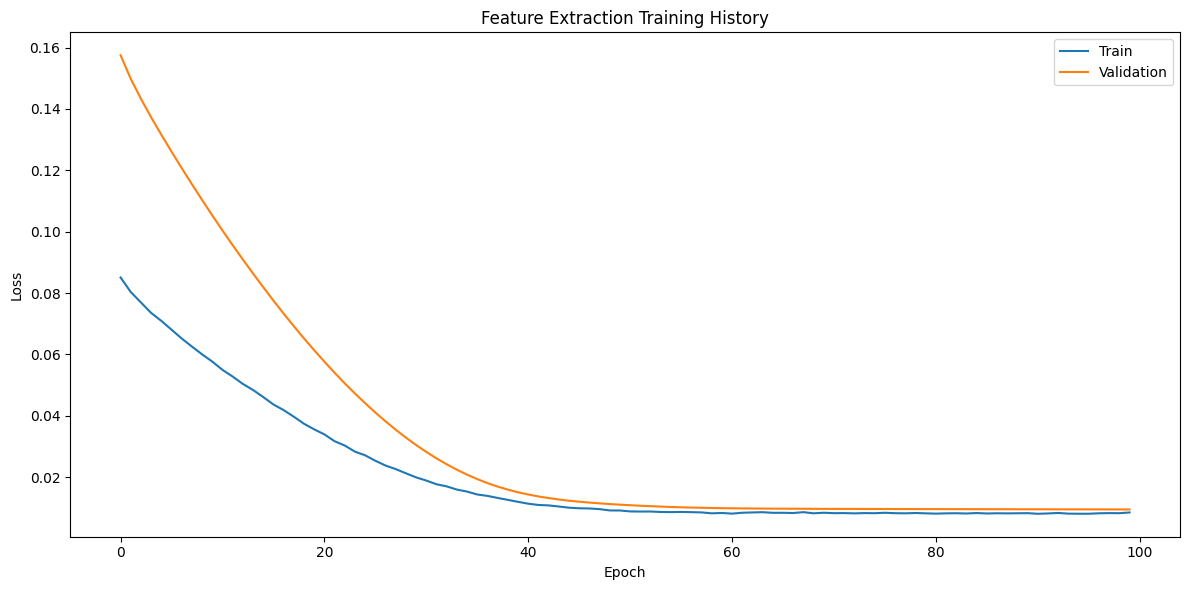

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11680\2831111490.py:508: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('feature_extract_model.p

成功加载特征提取的最佳模型

验证集评估结果:
Validation - MSE: 44.69, RMSE: 6.68, CVRMSE: 27.61%, R2: 0.8270, Accuracy: 80.57%


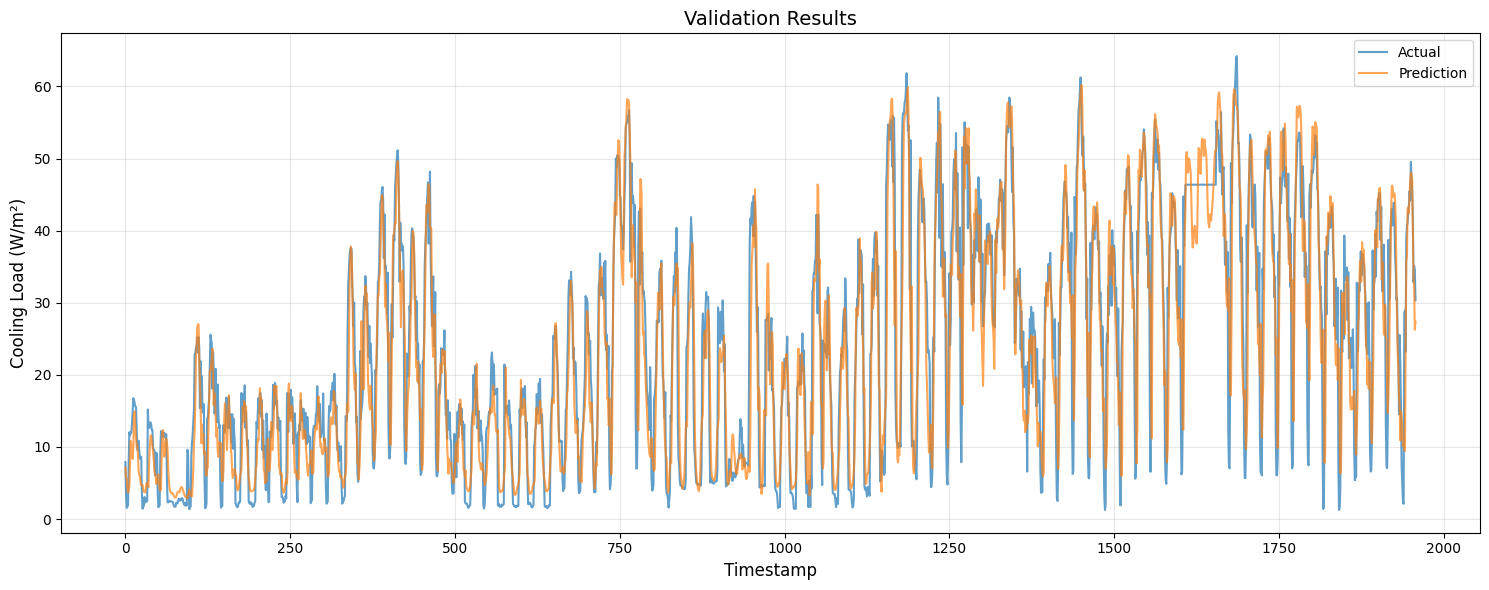


测试集评估结果:
Test - MSE: 27.19, RMSE: 5.21, CVRMSE: 18.33%, R2: 0.8642, Accuracy: 86.38%

Test Set Date Range:
Start: 2017-09-11 01:00
End: 2017-09-15 23:00
Days: 5 days (Mon, Tue, Wed, Thu, Fri


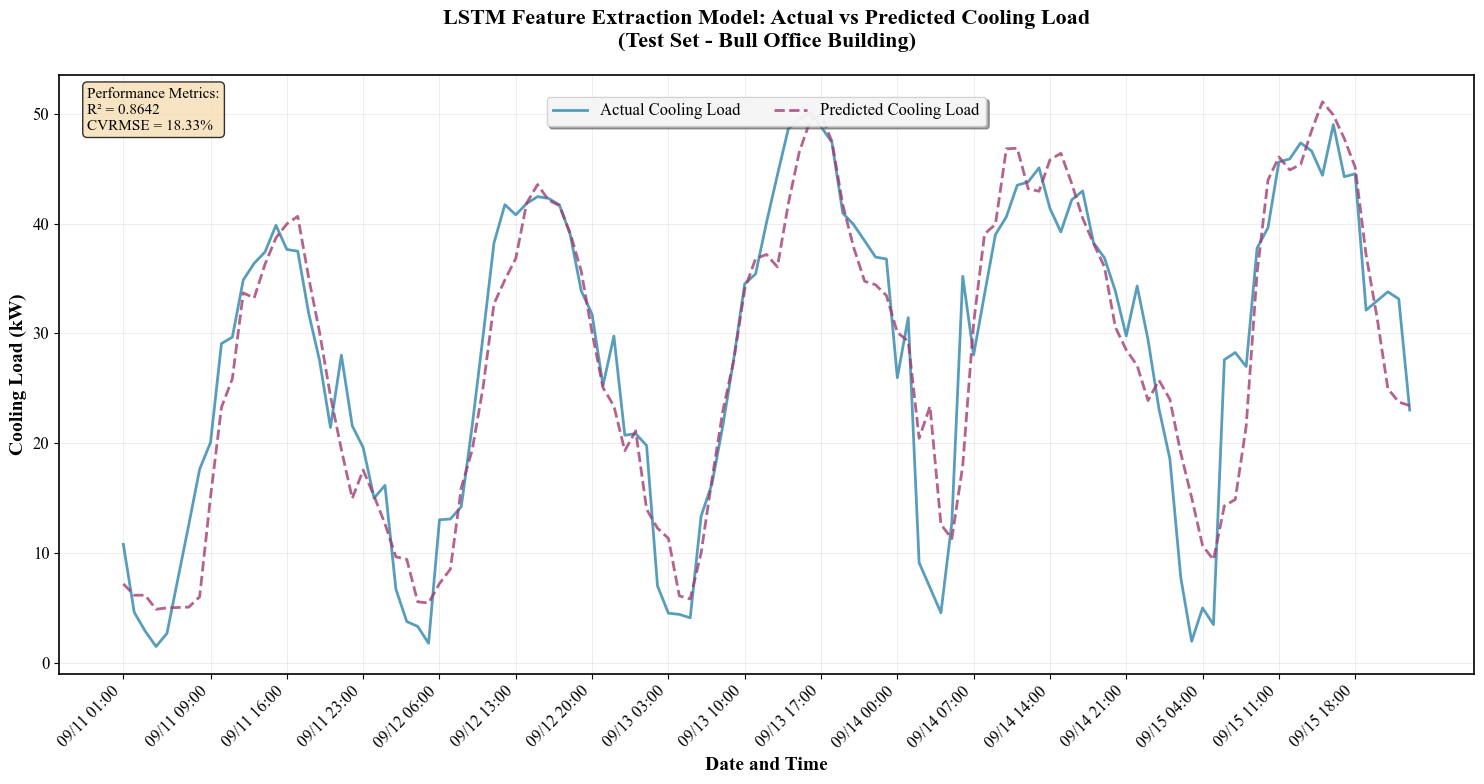

预测数据已保存至 'E:/bishe/BULL_lstm_feature_extract_predictions.csv'
LSTM特征提取模型保存到 'E:/bishe/BULL_lstm_feature_extract_model.pth'


In [3]:
# ==================== 辅助函数 ====================
def fill_lag_nan(df, ref_df, target_col):
    """精确填充滞后特征中的NaN值"""
    for col in df.columns:
        if 'lag_' in col:
            lag = int(col.split('_')[-1])
            # 使用参考数据集最后lag个有效值填充
            if not ref_df.empty:
                last_valid = ref_df[target_col].iloc[-lag:].dropna()
                if not last_valid.empty:
                    fill_value = last_valid.mean()
                else:
                    fill_value = 0  # 回退值
            else:
                fill_value = 0
            df[col] = df[col].fillna(fill_value)
    return df

def clean_data(df):
    """数据清洗函数"""
    # 填充NaN
    df = df.fillna(method='ffill').fillna(method='bfill')
    
    # 处理无穷大值
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].mean())
    return df

# ==================== 数据预处理 ====================
def load_and_preprocess(target_building=TARGET, return_raw=False, window_size=24):
    """支持指定目标建筑的数据加载，使用与LSTM一致的预处理方法"""
    data = pd.read_csv(DATA_SAVE_PATH, parse_dates=['timestamp'])
    
    # 筛选目标建筑数据
    building_columns = [col for col in data.columns 
                       if col.startswith(f"{SITE_ID}_{BUILDING_TYPE}_")]
    other_buildings = [col for col in building_columns if col != target_building]
    data = data.drop(columns=other_buildings)
    
    # 按月份划分数据集（与LSTM一致）
    data = data.sort_values('timestamp')
    data['year_month'] = data['timestamp'].dt.to_period('M')
    unique_months = data['year_month'].unique().tolist()
    
    # 数据集划分（与LSTM一致）
    train = data[data['year_month'].isin(unique_months[:15])]  # 前15个月
    val = data[data['year_month'].isin(unique_months[15:19])]  # 接下来5个月
    
    # ===== 测试集时间范围 =====
    test_start = pd.Timestamp('2017-09-08 00:00:00')
    test_end = pd.Timestamp('2017-09-16 00:00:00')
    test = data[(data['timestamp'] >= test_start) & (data['timestamp'] < test_end)]
    
    # 保存测试集时间戳
    test_timestamps = test['timestamp'].copy()
    
    # 特征工程（与LSTM一致）
    def add_features(df, target_col):
        df = df.copy()
        # 时间特征
        df['Hour'] = df['timestamp'].dt.hour
        df['DayOfWeek'] = df['timestamp'].dt.dayofweek
        
        # 周期特征
        df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
        df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
        df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
        df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
        
        # 滞后特征 - 只使用[1, 2, 3, 24, 48]
        for i in [1, 2, 3, 24, 48]:
            df[f'lag_{i}'] = df[target_col].shift(i)
            
        # 移动平均特征 - 使用shift(1)避免数据泄露
        df['3h_avg'] = df[target_col].rolling(3, min_periods=1).mean().shift(1)
        df['24h_avg'] = df[target_col].rolling(24, min_periods=1).mean().shift(1)
        
        # 交叉特征
        df['temp_humidity_ratio'] = df['airTemperature'] / (df['dewTemperature'] + 1e-6)
        
        return df.drop(columns=['Hour', 'DayOfWeek', 'year_month'])
    
    # 应用特征工程
    train = add_features(train, target_building)
    val = add_features(val, target_building)
    test = add_features(test, target_building)
    
    # 填充滞后特征缺失值
    val = fill_lag_nan(val, train, target_building)
    test = fill_lag_nan(test, pd.concat([train, val]), target_building)
    
    # 定义特征列 (确保一致性)
    features = [
        'airTemperature', 'dewTemperature', 'windSpeed', 'seaLvlPressure', 'occ_sch',
        'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos',
        'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48',
        '3h_avg', '24h_avg',
        'temp_humidity_ratio'
    ]
    
    # 检查特征是否存在
    missing_features = [f for f in features if f not in train.columns]
    if missing_features:
        print(f"警告: 以下特征不存在，已从列表中移除: {missing_features}")
        features = [f for f in features if f not in missing_features]
    
    # 数据清洗：处理NaN和Inf
    train = clean_data(train)
    val = clean_data(val)
    test = clean_data(test)
    
    # 数据归一化
    scaler_x = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    # 只使用训练集拟合归一化器
    X_train_scaled = scaler_x.fit_transform(train[features])
    y_train_scaled = scaler_y.fit_transform(train[[target_building]])
    
    # 检查数据有效性
    if np.isnan(X_train_scaled).any() or np.isnan(y_train_scaled).any():
        print("警告: 归一化后的训练数据包含NaN值")
        X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
        y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0)
    
    if np.isinf(X_train_scaled).any() or np.isinf(y_train_scaled).any():
        print("警告: 归一化后的训练数据包含Inf值")
        X_train_scaled = np.nan_to_num(X_train_scaled, posinf=1.0, neginf=0.0)
        y_train_scaled = np.nan_to_num(y_train_scaled, posinf=1.0, neginf=0.0)
    
    X_val_scaled = scaler_x.transform(val[features])
    y_val_scaled = scaler_y.transform(val[[target_building]])
    
    X_test_scaled = scaler_x.transform(test[features])
    y_test_scaled = scaler_y.transform(test[[target_building]])
    
    # 序列生成函数（与LSTM一致）
    def create_sequences(X, y, window):
        X_seq, y_seq = [], []
        for i in range(window, len(X)):
            X_seq.append(X[i-window:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    # 生成序列
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, window_size)
    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, window_size)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, window_size)
    
    # 调整时间戳索引
    test_timestamps_adjusted = test_timestamps.iloc[window_size:]
    
    if return_raw:
        return (X_train_seq, y_train_seq, 
                X_val_seq, y_val_seq, 
                X_test_seq, y_test_seq, 
                scaler_x, scaler_y, test_timestamps_adjusted)
    else:
        return (X_train_seq, y_train_seq, 
                X_val_seq, y_val_seq, 
                X_test_seq, y_test_seq, 
                scaler_x, scaler_y)

# ==================== 多源数据加载 ====================
def load_source_data(building_list, window_size=24):
    """加载多个源建筑数据并进行整合，使用与LSTM一致的预处理方法"""
    all_X, all_y = [], []
    for building in building_list:
        # 复用预处理流程
        X_train, y_train, X_val, y_val, X_test, y_test, scaler_x, scaler_y = load_and_preprocess(
            target_building=building, 
            return_raw=False, 
            window_size=window_size
        )
        
        # 合并所有数据（训练+验证+测试）
        X_combined = np.concatenate([X_train, X_val, X_test])
        y_combined = np.concatenate([y_train, y_val, y_test])
        
        all_X.append(X_combined)
        all_y.append(y_combined)
    
    # 合并所有数据
    X_combined = np.concatenate(all_X)
    y_combined = np.concatenate(all_y)
    
    return X_combined, y_combined

# ==================== LSTM模型 ====================
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers>1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
        # 参数初始化
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.fc.weight)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

class FeatureExtractModel(nn.Module):
    def __init__(self, pretrained_model):
        super().__init__()
        self.pretrained = pretrained_model
        
        # 冻结所有预训练参数（这是与微调的唯一区别）
        for param in self.pretrained.parameters():
            param.requires_grad = False
                
        # 新增可训练层
        self.new_fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        features, _ = self.pretrained.lstm(x)
        features = features[:, -1, :]
        return self.new_fc(features)

# ==================== 训练函数 ====================
def train_model(model, train_loader, val_loader, device, 
               num_epochs=100, is_feature_extract=False, init_lr=0.001,
               model_save_path='best_model.pth'):
    """使用与LSTM一致的训练参数：学习率0.0001，批次大小32，梯度裁剪0.5"""
    # 分层学习率设置
    if is_feature_extract:
        optimizer = optim.RMSprop(model.new_fc.parameters(), lr=init_lr*0.1)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=init_lr)
    
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=30)
    criterion = nn.MSELoss()
    
    best_loss = float('inf')
    history = {'train': [], 'val': []}
    patience = 0  # 初始化耐心计数器
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}')
        
        for inputs, targets in progress_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # 检查损失是否为NaN
            if torch.isnan(loss):
                print(f"NaN损失出现在第 {epoch+1} 轮")
                progress_bar.close()
                return history
                
            loss.backward()
            
            # 梯度裁剪（与LSTM一致：0.5）
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            
            optimizer.step()
            
            train_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # 验证阶段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item()
        
        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        history['train'].append(avg_train)
        history['val'].append(avg_val)
        
        scheduler.step(avg_val)
        
        # 保存最佳模型
        if avg_val < best_loss:
            best_loss = avg_val
            torch.save(model.state_dict(), model_save_path)
            patience = 0
        else:
            patience += 1
            if patience >= 30:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        print(f'Epoch {epoch+1}: Train Loss={avg_train:.4f}, Val Loss={avg_val:.4f}')

    return history

# ==================== 时间序列交叉验证预训练 ====================
def pretrain_with_cv(building_list, window_size=24, n_splits=3):
    """使用时间序列交叉验证预训练模型"""
    print(f"\n=== 使用 {n_splits} 折时间序列交叉验证进行预训练 ===")
    
    # 加载所有源数据
    X_all, y_all = load_source_data(building_list, window_size)
    
    # 创建时间序列交叉验证对象
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # 存储每折的最佳模型和损失
    best_models = []
    best_losses = []
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 获取输入特征维度
    input_size = X_all.shape[2]
    
    # 进行交叉验证
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
        print(f"\n--- 训练第 {fold+1}/{n_splits} 折 ---")
        
        # 划分训练集和验证集
        X_train, X_val = X_all[train_idx], X_all[val_idx]
        y_train, y_val = y_all[train_idx], y_all[val_idx]
        
        # 创建DataLoader
        train_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
            batch_size=128, shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
            batch_size=128
        )
        
        # 初始化模型
        model = EnhancedLSTM(input_size=input_size).to(device)
        
        # 训练模型
        model_path = f'pretrained_model_fold_{fold+1}.pth'
        history = train_model(model, train_loader, val_loader, device, 
                             num_epochs=100, init_lr=0.001,
                             model_save_path=model_path)
        
        # 加载最佳模型并记录损失
        if os.path.exists(model_path):
            model.load_state_dict(torch.load(model_path))
            best_models.append(model)
            
            # 计算最佳验证损失
            model.eval()
            val_loss = 0
            criterion = nn.MSELoss()
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    val_loss += criterion(outputs, targets).item()
            
            avg_val_loss = val_loss / len(val_loader)
            best_losses.append(avg_val_loss)
            print(f"第 {fold+1} 折最佳验证损失: {avg_val_loss:.4f}")
        else:
            print(f"警告: 第 {fold+1} 折未找到保存的模型")
    
    # 选择最佳模型（验证损失最小的模型）
    if best_losses:
        best_fold = np.argmin(best_losses)
        best_model = best_models[best_fold]
        print(f"\n选择第 {best_fold+1} 折的模型作为预训练模型 (验证损失: {best_losses[best_fold]:.4f})")
        
        # 保存最佳预训练模型
        torch.save(best_model.state_dict(), 'pretrained_model.pth')
        print("最佳预训练模型已保存为 'pretrained_model.pth'")
        
        return best_model
    else:
        print("错误: 所有折的训练都失败了")
        return None

# ==================== 评估函数 ====================
def evaluate_model(model, loaders, scaler_y, device, test_timestamps=None):
    model.eval()
    results = {}
    
    for phase in ['val', 'test']:
        preds, trues = [], []
        with torch.no_grad():
            for inputs, targets in loaders[phase]:
                inputs = inputs.to(device)
                outputs = model(inputs).cpu().numpy()
                preds.extend(outputs)
                trues.extend(targets.numpy())
        
        # 反归一化
        preds = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1))
        trues = scaler_y.inverse_transform(np.array(trues).reshape(-1, 1))
        
        # 计算指标
        mse = mean_squared_error(trues, preds)
        rmse = math.sqrt(mse)
        cvrmse = rmse / np.mean(trues) * 100
        mae = mean_absolute_error(trues, preds)
        r2 = r2_score(trues, preds)
        accuracy = (1 - mae / np.mean(trues)) * 100
        
        results[phase] = {
            'preds': preds,
            'trues': trues,
            'mse': mse,
            'rmse': rmse,
            'cvrmsre': cvrmse,
            'mae': mae,
            'r2': r2,
            'accuracy': accuracy
        }
        
        # 如果是测试集且提供了时间戳，则添加时间戳信息
        if phase == 'test' and test_timestamps is not None:
            results[phase]['timestamps'] = test_timestamps
    
    return results

# ==================== 主程序 ====================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 删除旧的模型文件 - 使用不同文件名避免冲突
    model_files = ['pretrained_model.pth', 'feature_extract_model.pth']
    for file in model_files:
        if os.path.exists(file):
            os.remove(file)
            print(f"已删除旧的模型文件: {file}")
    
    # === 第一阶段：使用时间序列交叉验证预训练源模型 ===
    src_model = pretrain_with_cv(SOURCE_BUILDINGS, n_splits=3)
    
    if src_model is None:
        print("预训练失败，退出程序")
        exit(1)
    
    # === 第二阶段：特征提取迁移学习 ===
    print("\n=== 特征提取迁移学习 ===")
    # 加载目标建筑数据（包含测试集时间戳）
    X_train, y_train, X_val, y_val, X_test, y_test, scaler_x, scaler_y, test_timestamps = load_and_preprocess(
        target_building=TARGET, 
        return_raw=True
    )
    
    # 创建DataLoader（批次大小128，与LSTM一致）
    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=128, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=128
    )
    test_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)),
        batch_size=128
    )
    
    # 初始化特征提取模型
    model = FeatureExtractModel(src_model).to(device)
    
    # 特征提取训练（学习率0.001，与LSTM一致）使用专用文件名
    feature_extract_history = train_model(model, train_loader, val_loader, device, 
                                        num_epochs=100, is_feature_extract=True, init_lr=0.0001,
                                        model_save_path='feature_extract_model.pth')
    
    # === 可视化训练过程 ===
    plt.figure(figsize=(12,6))
    plt.plot(feature_extract_history['train'], label='Train')
    plt.plot(feature_extract_history['val'], label='Validation')
    plt.title('Feature Extraction Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig("E:/bishe/BULL_lstm_feature_extract_training_history.png", dpi=300)
    plt.show()
    
    # === 模型评估 ===
    if os.path.exists('feature_extract_model.pth'):
        model.load_state_dict(torch.load('feature_extract_model.pth'))
        print("成功加载特征提取的最佳模型")
        
        loaders = {'val': val_loader, 'test': test_loader}
        results = evaluate_model(model, loaders, scaler_y, device, test_timestamps)
        
        # 验证集结果
        val_results = results['val']
        print("\n验证集评估结果:")
        print("Validation - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
              % (val_results['mse'], val_results['rmse'], val_results['cvrmsre'], 
                 val_results['r2'], val_results['accuracy']))

        # 绘制验证集结果（与LSTM一致）
        plt.figure(figsize=(15, 6))
        plt.plot(val_results['trues'], label='Actual', alpha=0.7)
        plt.plot(val_results['preds'], label='Prediction', alpha=0.7)
        plt.xlabel("Timestamp", fontsize=12)
        plt.ylabel("Cooling Load (W/m²)", fontsize=12)
        plt.title("Validation Results", fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig("E:/bishe/BULL_lstm_feature_extract_validation_results.png", dpi=300)
        plt.show()

        # 测试集结果
        test_results = results['test']
        test_timestamps = test_results['timestamps']
        
        print("\n测试集评估结果:")
        print("Test - MSE: %.2f, RMSE: %.2f, CVRMSE: %.2f%%, R2: %.4f, Accuracy: %.2f%%" 
              % (test_results['mse'], test_results['rmse'], test_results['cvrmsre'], 
                 test_results['r2'], test_results['accuracy']))
        
        # 输出测试集日期范围
        print("\nTest Set Date Range:")
        print(f"Start: {test_timestamps.min().strftime('%Y-%m-%d %H:%M')}")
        print(f"End: {test_timestamps.max().strftime('%Y-%m-%d %H:%M')}")
        print(f"Days: {test_timestamps.dt.date.nunique()} days ({', '.join(test_timestamps.dt.strftime('%a').unique())}")

        # ================ SCI级别的测试集可视化 ================
        plt.rcParams['font.family'] = 'Times New Roman'
        plt.rcParams['font.size'] = 12
        plt.rcParams['axes.linewidth'] = 1.2

        # 创建图形，调整上方空间
        fig, ax = plt.subplots(figsize=(15, 8))
        fig.subplots_adjust(top=0.90)  # 调整顶部边距，为标签留出空间

        # 绘制实际值和预测值
        line_actual, = ax.plot(test_timestamps, test_results['trues'], 
                              label='Actual Cooling Load', 
                              color='#2E86AB', linewidth=2, alpha=0.8)
        line_pred, = ax.plot(test_timestamps, test_results['preds'], 
                            label='Predicted Cooling Load', 
                            color='#A23B72', linewidth=2, alpha=0.8, linestyle='--')

        # 格式化日期标签
        if hasattr(test_timestamps, 'dt'):
            date_labels = test_timestamps.dt.strftime('%m/%d %H:%M')
            n = len(test_timestamps)
            step = max(1, n // 15)  # 减少标签数量以提高可读性
            
            # 设置x轴刻度和标签
            ax.set_xticks(test_timestamps[::step])
            ax.set_xticklabels(date_labels[::step], rotation=45, ha='right')
            ax.set_xlabel('Date and Time', fontsize=14, fontweight='bold')

        # 添加网格线
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

        # 设置y轴标签
        ax.set_ylabel('Cooling Load (kW)', fontsize=14, fontweight='bold')

        # 添加图例 - 横排排列在图的最上方
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.9), 
                  frameon=True, fancybox=True, shadow=True, 
                  framealpha=0.9, fontsize=12, ncol=2)

        # 在图上添加性能指标文本框 - 只使用R2和CVRMSE
        metrics_text = f'Performance Metrics:\nR² = {test_results["r2"]:.4f}\nCVRMSE = {test_results["cvrmsre"]:.2f}%'
        ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.8), fontsize=11)

        # 设置标题 - 调整位置避免遮挡
        ax.set_title('LSTM Feature Extraction Model: Actual vs Predicted Cooling Load\n(Test Set - Bull Office Building)', 
                     fontsize=16, fontweight='bold', pad=20)

        # 调整布局
        plt.tight_layout()

        # 保存为SVG格式
        plt.savefig("E:/bishe/BULL_lstm_feature_extract_test_results.svg", format='svg', dpi=300, bbox_inches='tight')
        plt.savefig("E:/bishe/BULL_lstm_feature_extract_test_results.png", dpi=300, bbox_inches='tight')
        plt.show()

        # 保存预测数据用于后续合并分析
        prediction_data = pd.DataFrame({
            'timestamp': test_timestamps,
            'actual': test_results['trues'].flatten(),
            'predicted': test_results['preds'].flatten()
        })
        prediction_data.to_csv("E:/bishe/BULL_lstm_feature_extract_predictions.csv", index=False)
        print("预测数据已保存至 'E:/bishe/BULL_lstm_feature_extract_predictions.csv'")
        
        # 保存模型
        torch.save(model.state_dict(), 'E:/bishe/BULL_lstm_feature_extract_model.pth')
        print("LSTM特征提取模型保存到 'E:/bishe/BULL_lstm_feature_extract_model.pth'")
    else:
        print("警告：未找到特征提取的最佳模型文件")